# Figurative vs Literal Language Classification using BERT Embeddings (Project P8)

In this project, we investigate how well contextual word representations from BERT can separate figurative and literal language.
We use the VU Amsterdam Metaphor Corpus (VUA AMC) as our main dataset and formulate the task as a binary sentence-level
classification problem:

- **literal**: the sentence does not primarily rely on metaphorical or figurative usage,
- **figurative**: the sentence contains metaphorical or figurative expressions.

We extract sentence embeddings with a pretrained BERT model and train a simple linear classifier (Logistic Regression).
We additionally use dimensionality reduction techniques (PCA, t-SNE, UMAP) to visualise the structure of the embedding space.
Finally, we evaluate the model with standard classification metrics and analyse the confusion matrix.


In [38]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import os
import math
import time
import json
import torch
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import umap

In [39]:
# Path to the preprocessed CSV file containing literal and figurative sentences.
DATA_PATH = '/Users/aissolaa/Desktop/NLP_projects/literal_figurative.csv'

df = pd.read_csv(DATA_PATH, encoding='utf-8')

# Ensure that the dataset includes the required columns: 'text' (sentence) and 'label' (class).
required_cols = {'text','label'}
if not required_cols.issubset(set(df.columns)):
    raise ValueError(f'DataFrame must contain columns: {required_cols}')

# This numeric mapping is required for model training and evaluation.
label_map = {'literal':0, 'figurative':1}
df['label_num'] = df['label'].map(label_map)

# Print total number of samples and class distribution for initial inspection.
print(f"Loaded {len(df)} rows.")
print("Label distribution:")
print(df['label'].value_counts()) 


Loaded 15516 rows.
Label distribution:
label
literal       11187
figurative     4329
Name: count, dtype: int64


In [40]:
# Upload a dataset
df = pd.read_csv("/Users/aissolaa/Desktop/NLP_projects/literal_figurative.csv", encoding='utf-8')

# Take a subsample of 2000 lines 
literal_figurative_subset = df.iloc[:2000].copy()

# Print the 5 
literal_figurative_subset.head(5)

,text,label
0,Ca n't fail to be entertaining .,literal
1,How much was he going to tell her ?,literal
2,"Up until that news hit the Committee , Don had...",literal
3,Could go on to the rugby and go with them coul...,literal
4,"Finally , we went to the office and they gave ...",literal


## Exploratory Data Analysis

In this section we briefly inspect the dataset: class distribution, sentence length, and example sentences for each class.

Head of the dataframe:


,text,label
0,Ca n't fail to be entertaining .,literal
1,How much was he going to tell her ?,literal
2,"Up until that news hit the Committee , Don had...",literal
3,Could go on to the rugby and go with them coul...,literal
4,"Finally , we went to the office and they gave ...",literal


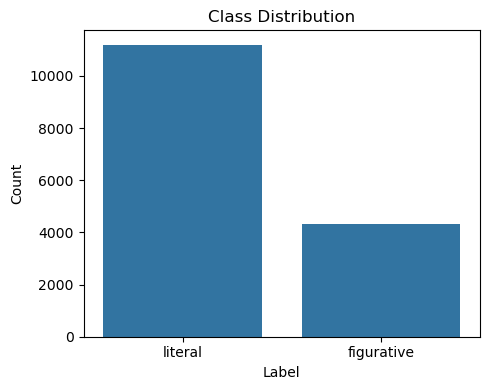

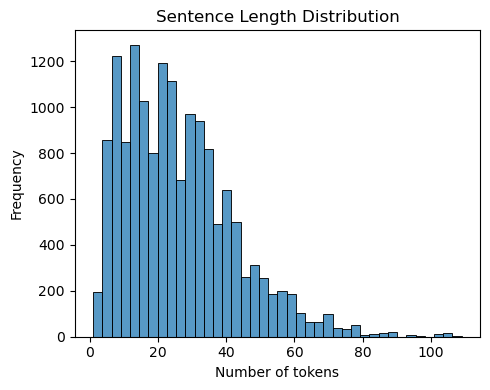


Sentence length by label (summary):


text_len                                            
              count   mean    std  min   25%   50%   75%    max
label                                                          
figurative   4329.0  28.07  15.45  2.0  16.0  26.0  37.0  106.0
literal     11187.0  25.35  16.53  1.0  12.0  22.0  34.0  109.0


LITERAL EXAMPLES:
- He turned and smiled at Adam .
- Frantically she tore open the door to Elinor 's apartment .
- To confirm .

FIGURATIVE EXAMPLES:
- The council appealed by case stated .
- Has Moscow any suggestions as to how we should proceed ?
- He was n't here to make jokes .


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Head of the dataframe:")
display(df.head())

# Class distribution
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Sentence length distribution
df['text_len'] = df['text'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(5,4))
sns.histplot(df['text_len'], bins=40)
plt.title('Sentence Length Distribution')
plt.xlabel('Number of tokens')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\nSentence length by label (summary):")
display(df[['label','text_len']].groupby('label').describe().round(2))

# Print a few random examples per class
for lbl in ['literal', 'figurative']:
    print(f"\n{lbl.upper()} EXAMPLES:")
    samples = df[df['label'] == lbl].sample(min(3, (df['label'] == lbl).sum()), random_state=42)
    for t in samples['text']:
        print("-", t)

In [42]:
# Strictly limit the sample size so as not to kill memory
MAX_SAMPLES = 2000  

if len(df) > MAX_SAMPLES:
    df_small = df.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)
    print(f"Dataset too large ({len(df)} rows). Using random subset of {len(df_small)} rows.")
else:
    df_small = df.copy().reset_index(drop=True)
    print(f"Using all {len(df_small)} rows.")

Dataset too large (15516 rows). Using random subset of 2000 rows.


In [47]:
from typing import List

# Load BERT model and tokenizer
# Use the pre-trained BERT-base-uncased model to generate contextual embeddings.
MODEL_NAME = 'bert-base-uncased'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()  # disable training mode for inference 

# Define a function to compute embeddings in batches
def get_embeddings_batch(sentences: List[str],
                         batch_size: int = 16,
                         pooling: str = 'cls',
                         max_length: int = 64) -> np.ndarray:

    # Validate pooling type
    if pooling not in {'cls', 'mean'}:
        raise ValueError('pooling must be "cls" or "mean"')

    all_embs = []  # container for batch embeddings

    # Disable gradient computation for efficiency
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(sentences), batch_size), desc='Embedding batches'):
            # Slice current batch
            batch = sentences[i:i+batch_size]

            # Tokenize sentences with padding and truncation
            inputs = tokenizer(
                batch,
                return_tensors='pt',
                padding=True,
                truncation=True,
                max_length=max_length
            )
            # Move input tensors to selected device (CPU/GPU)
            inputs = {k: v.to(device) for k, v in inputs.items()}

            # Forward pass through BERT (no gradients)
            outputs = model(**inputs)
            last_hidden = outputs.last_hidden_state  # (B, L, H)

            if pooling == 'cls':
                emb = last_hidden[:, 0, :]           # (B, H)
            else:
                emb = last_hidden.mean(dim=1)        # (B, H)

            all_embs.append(emb.cpu().numpy())

    X = np.concatenate(all_embs, axis=0)
    return X


Device: cpu


In [48]:
# make sure that label_num is there
if 'label_num' not in df.columns:
    df['label_num'] = df['label'].map({'literal': 0, 'figurative': 1})

# if the df_small was created earlier, recreate it with this column
df_small = df.sample(n=2000, random_state=42).reset_index(drop=True)

sentences = df_small['text'].astype(str).tolist()
X = get_embeddings_batch(sentences, batch_size=8, pooling='cls', max_length=64)
print('Embeddings shape:', X.shape)

y = df_small['label_num'].values


Embedding batches:   0%|          | 0/250 [00:00<?, ?it/s]

Embeddings shape: (2000, 768)


In [49]:
# Counting embeddings for a reduced dataset
sentences = df_small['text'].astype(str).tolist()
X = get_embeddings_batch(sentences, batch_size=8, pooling='cls', max_length=64)
print('Embeddings shape:', X.shape)

y = df_small['label_num'].values

emb_df = pd.DataFrame(X)
emb_df['text'] = df_small['text'].values
emb_df['label'] = df_small['label'].values
emb_df['label_num'] = df_small['label_num'].values
emb_df.to_pickle('embeddings_df.pkl')
emb_df.to_csv('embeddings_df.csv', index=False)
print('Saved embeddings_df.pkl and embeddings_df.csv')


Embedding batches:   0%|          | 0/250 [00:00<?, ?it/s]

Embeddings shape: (2000, 768)
Saved embeddings_df.pkl and embeddings_df.csv


PCA computed and saved
Saved plot: pca_plot.png


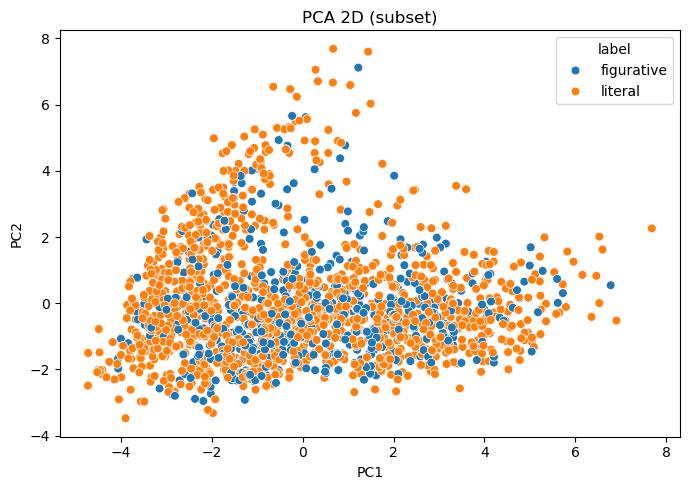

In [51]:
# PCA
results = {}

try:
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    results['pca'] = X_pca
    np.save('X_pca.npy', X_pca)
    pd.DataFrame(X_pca, columns=['pc1', 'pc2']).assign(label=df_small['label']).to_csv('X_pca.csv', index=False)
    print('PCA computed and saved')
except Exception as e:
    print('PCA failed:', repr(e))

# Draw PCA scatter plot
if 'pca' in results:
    arr = results['pca']
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(x=arr[:, 0], y=arr[:, 1], hue=df_small['label'], s=40, ax=ax)
    ax.set_title('PCA 2D (subset)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.tight_layout()
    fname = 'pca_plot.png'
    fig.savefig(fname)
    print(f'Saved plot: {fname}')
    plt.show()

Cross-validated accuracy (5-fold): 0.6556 (std 0.0220)

Test set performance:
Accuracy: 0.7075
F1-score: 0.4121

Classification report:
               precision    recall  f1-score   support

     literal       0.77      0.85      0.81       285
  figurative       0.49      0.36      0.41       115

    accuracy                           0.71       400
   macro avg       0.63      0.60      0.61       400
weighted avg       0.69      0.71      0.69       400



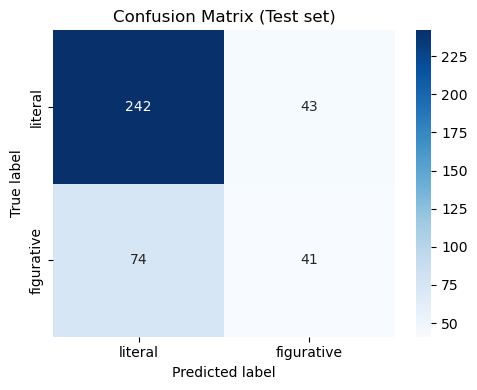

In [52]:
# Logistic Regression + train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

clf = LogisticRegression(max_iter=1000)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')

print('Cross-validated accuracy (5-fold): {:.4f} (std {:.4f})'
      .format(scores.mean(), scores.std()))

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('\nTest set performance:')
print('Accuracy:', round(acc, 4))
print('F1-score:', round(f1, 4))

print('\nClassification report:\n', classification_report(y_test, y_pred, target_names=['literal', 'figurative']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['literal', 'figurative'],
    yticklabels=['literal', 'figurative']
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Test set)')
plt.tight_layout()
plt.show()

## Error Analysis

Inspect examples where the classifier makes mistakes to better understand the remaining challenges in figurative language detection.

Text(0.5, 1.0, 'PCA projection of BERT embeddings')

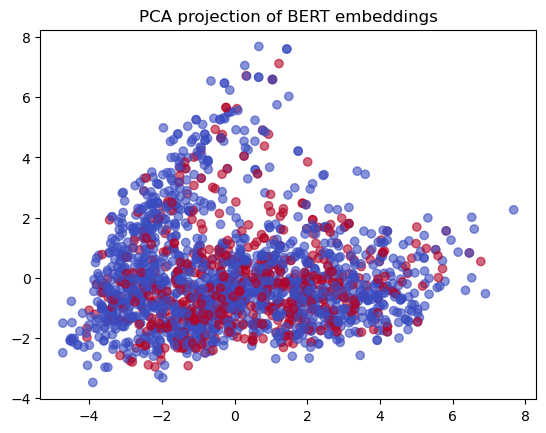

In [53]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.6)
plt.title("PCA projection of BERT embeddings")


In [54]:
# Error analysis

try:
    import pandas as pd

    # Build a DataFrame with test texts and predictions.
    df_test_results = pd.DataFrame({
        'text': df_small.iloc[-len(y_test):]['text'].values,
        'true_label': ['literal' if y == 0 else 'figurative' for y in y_test],
        'pred_label': ['literal' if y == 0 else 'figurative' for y in y_pred],
    })

    errors = df_test_results[df_test_results['true_label'] != df_test_results['pred_label']]
    print(f"Total misclassified examples: {len(errors)}")
    display(errors.head(10))
except Exception as e:
    print("Error analysis cell could not run:", repr(e))
    print("pipeline.")


Total misclassified examples: 117


,text,true_label,pred_label
4,"Experience with practical calculations helps ,...",figurative,literal
7,Villages and refugee camps were thus being dev...,figurative,literal
13,The same applies to the general deterrent argu...,literal,figurative
14,Since the latter are available for a 5 km rast...,figurative,literal
15,"In general , the research work of the internat...",figurative,literal
23,Another hotel that would make a good starting ...,literal,figurative
24,A male friend had tried to dissuade Hale from ...,figurative,literal
25,"Something that will interest you , Adam , some...",figurative,literal
26,"In saying that hang on , no , hang on .",figurative,literal
31,THE ALL BLACKS begin the Irish leg of their 13...,literal,figurative


## Conclusion

In this project, I explored how figurative and literal language are represented in the embedding space of a pretrained BERT model.
Sentence embeddings were extracted using `bert-base-uncased` and a simple linear classifier (Logistic Regression) was trained on top
of these representations.

The results show that:
- The model reaches around **70% accuracy** on the held-out test set.
- Literal sentences are generally easier to classify than figurative ones: precision and recall are higher for the *literal* class,
  while figurative expressions remain more challenging.
- PCA visualisation of the embedding space suggests partial separability between figurative and literal sentences, but with
  substantial overlap, which reflects the inherent ambiguity and context-dependence of figurative language.

These findings indicate that contextualised embeddings already encode useful information about figurative meaning, but more advanced
approaches (such as fine-tuning, non-linear classifiers, or multi-task learning) are likely needed to achieve higher performance.

## References

- Steen, G. J., Dorst, A. G., Herrmann, J. B., Kaal, A. A., Krennmayr, T., & Pasma, T. (2010). *A Method for Linguistic Metaphor Identification: From MIP to MIPVU*. John Benjamins.
- Kulkarni, S., Saakyan, A., Chakrabarty, T., & Muresan, S. (2024). *A Report on the FigLang 2024 Shared Task on Multimodal Figurative Language*. Proceedings of the 4th Workshop on Figurative Language Processing (FigLang 2024).
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*.
